# Tutorial 5: Aligning spatial transcriptomics data to spatial metabolomics data of mouse brain slices

## Data Preparation

Please download the required data files from the provided link:
[Download here](https://pan.baidu.com/s/17K1cmxOPmhSvV6dG6gnafw?pwd=sjbx)

- `B1_SM.h5ad`
- `C1_ST.h5ad`

After downloading, place both files into the `datasets` folder located in the same directory as this notebook.

The folder structure should be organized as follows:

```
project_root/
│
├── datasets/
│   └── MB_STM/
│       ├── B1_SM.h5ad
│       └── C1_ST.h5ad
│
├── Tutorial5_Aligning_spatial_transcriptomics_data_to_spatial_metabolomics_data_of_mouse_brain_slices.ipynb
│
└── SpaMOMA/
```

## import packages

In [1]:
import scanpy as sc
import anndata
from SpaMOMA.SpaMOMA import SpaMOMA

## Specify Slice Metadata

In [2]:
save_directory = "./SpaMOMA_output/MB_STM/"  
spamoma = SpaMOMA(save_dir=save_directory)
spamoma.add_slice(
    sample_id="B1_SM",  
    raw_data_path="./datasets/MB_STM/B1_SM.h5ad",  
    feature="metabolite"  
)
spamoma.add_slice(
    sample_id="C1_ST", 
    raw_data_path="./datasets/MB_STM/C1_ST.h5ad", 
    feature="rna"  
)
spamoma.set_reference('B1_SM')
print(f"aligning {[sid for sid in spamoma.input_slice_dict.keys() if sid != spamoma.reference_sample_id]} to {spamoma.reference_sample_id}")

aligning ['C1_ST'] to B1_SM


## Data Preprocessing

preprocessing metabolite features...


------Calculating spatial graph...


The graph contains 21686 edges, 3098 cells.
7.0000 neighbors per cell on average.
Size of Input:  (3098, 100)


2026-02-19 21:24:38.929878: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-02-19 21:24:38.938661: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled



100%|██████████| 500/500 [00:31<00:00, 15.67it/s]

preprocessing rna features...


------Calculating spatial graph...


The graph contains 20349 edges, 2907 cells.
7.0000 neighbors per cell on average.
Size of Input:  (2907, 3000)


2026-02-19 21:25:13.623291: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



100%|██████████| 500/500 [00:40<00:00, 12.21it/s]

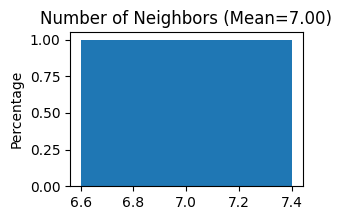

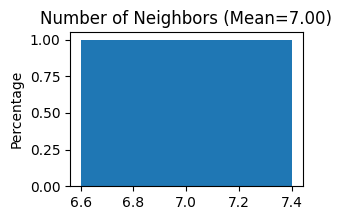

In [3]:
spamoma.preprocess_input_slices()

## Generate Spatial Pattern Images

generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"1.2


saving image...


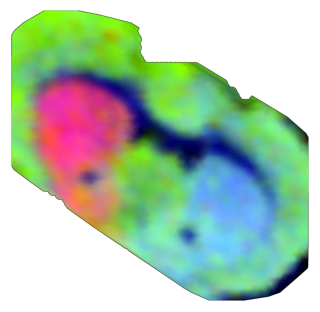

Img for B1_SM is saved to ./SpaMOMA_output/MB_STM/B1_SM/RGB.png
generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"1.2


saving image...


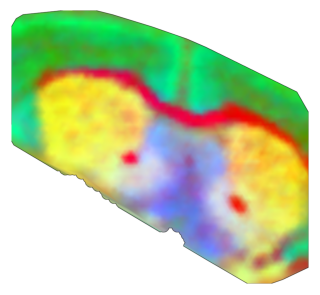

Img for C1_ST is saved to ./SpaMOMA_output/MB_STM/C1_ST/RGB.png


In [4]:
spamoma.generate_imgs()

In [5]:
spamoma.input_slice_dict

{'B1_SM': {'sample_id': 'B1_SM',
  'raw_data_path': './datasets/MB_STM/B1_SM.h5ad',
  'feature': 'metabolite',
  'pseudo_color_key': 'pca',
  'processed_data': AnnData object with n_obs × n_vars = 3098 × 100
      obs: 'array_row', 'array_col', 'ground_truth', 'spot_x', 'spot_y', 'img_x', 'img_y', 'batch', 'my_pixel_x', 'my_pixel_y'
      var: 'metabolism', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns: 'hvg', 'log1p', 'spatial_neighbors', 'moranI'
      obsm: 'spatial', 'pca'
      obsp: 'spatial_connectivities', 'spatial_distances',
  'SPI_path': './SpaMOMA_output/MB_STM/B1_SM/RGB.png'},
 'C1_ST': {'sample_id': 'C1_ST',
  'raw_data_path': './datasets/MB_STM/C1_ST.h5ad',
  'feature': 'rna',
  'pseudo_color_key': 'pca',
  'processed_data': AnnData object with n_obs × n_vars = 2907 × 3000
      obs: 'in_tissue', 'array_row', 'array_col', 'coord', 'ground_truth', 'spot_x', 'spot_y', 'img_x', 'img_y', 'batch', 'my_pixel_x', 'my_pixel_y'
      

## Model Training

In [6]:
spamoma.train(coarse_epochs=1000,fine_epochs=600,parallel_mode=True,coarse_gpu=2,fine_gpu=2)

start coarse adaptation...
start fine adaptation...


fine adaptation done!
coarse adaptation done!


## Slice Alignment

aligned B1_SM adata is saved to: ./SpaMOMA_output/MB_STM//alignment_output/B1_SM.h5ad
****************** aligning C1_ST to B1_SM ..... ******************
start coarse alignment...
match params: {'model_key': 'roma', 'match_threshold': 0.999, 'extract_max_keypoints': 4096, 'force_resize': True, 'image_height': 560, 'image_width': 560, 'choice_geometry_type': 'Homography'}
Loading Roma model: ./SpaMOMA_output/MB_STM/coarse_model/adapted_model_epoch_1000.pth
current Roma instance ID: 128943469159040
preprocessing is already resized
Force resize to 560x560


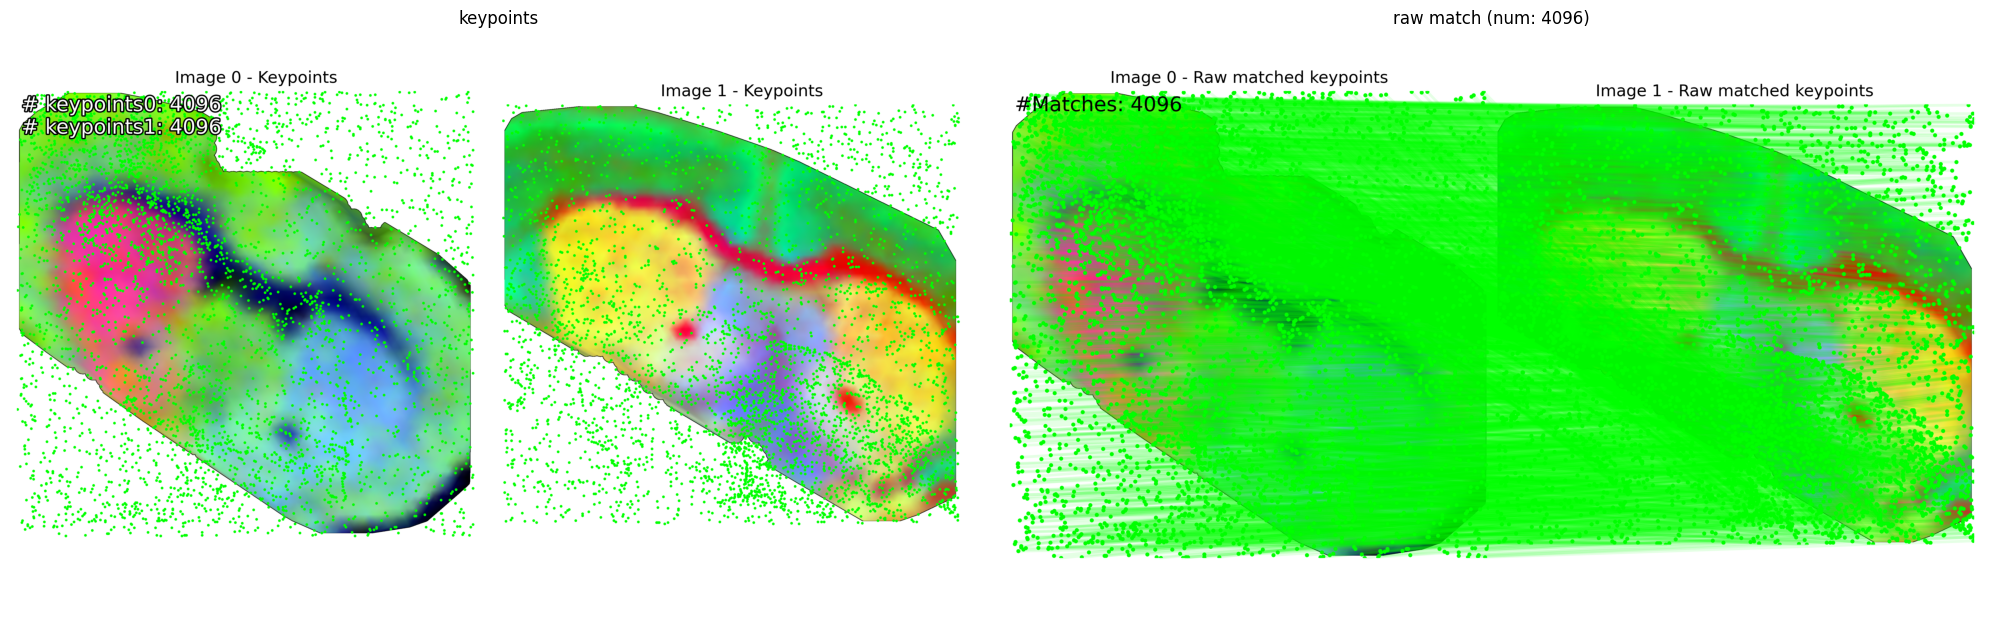


Matching statistics:
- Number of raw match points: 4096
coarse alignment done!
start fine alignment...
Loading Roma model: ./SpaMOMA_output/MB_STM/fine_model/adapted_model_epoch_600.pth
current Roma instance ID: 128942363506384
preprocessing is already resized
Force resize to 560x560


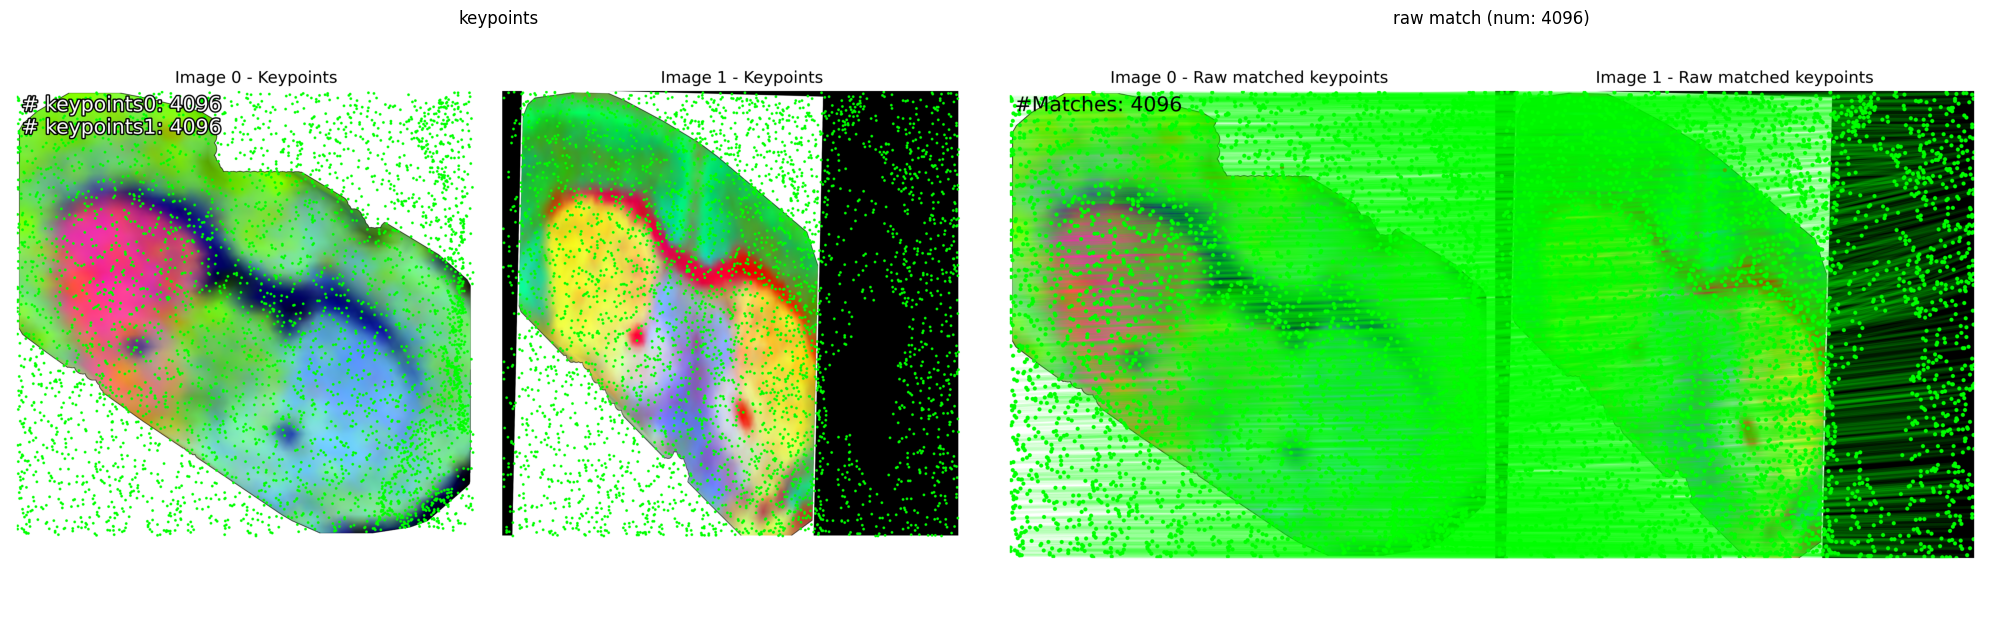


Matching statistics:
- Number of raw match points: 4096


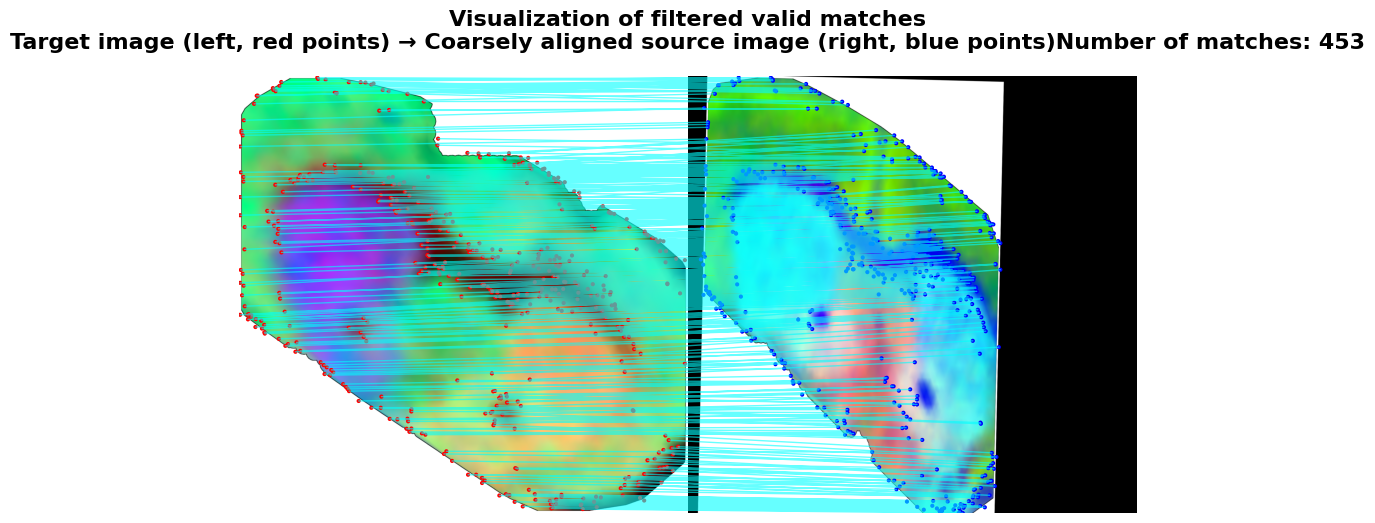

aligned C1_ST adata is saved to: ./SpaMOMA_output/MB_STM//alignment_output/C1_ST.h5ad
fine alignment done!


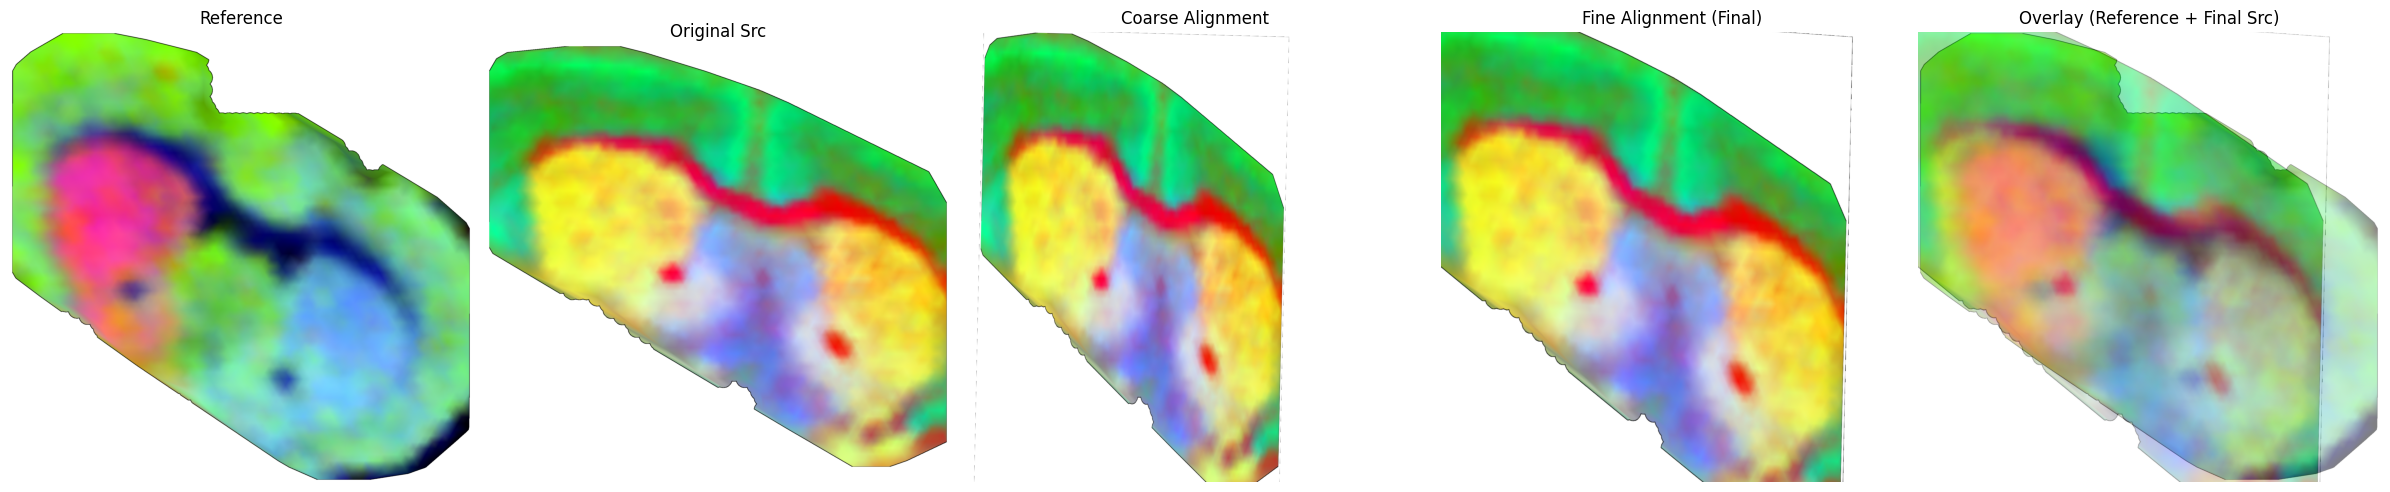

In [ ]:
spamoma.align_slices(visualize_correspondences=True)

## Visualize Alignment Results

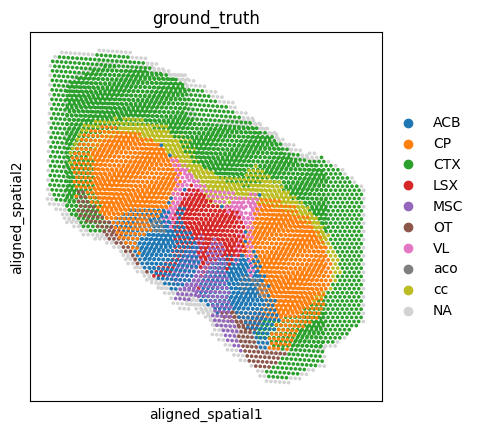

In [ ]:
adata1=spamoma.read_aligned_data('B1_SM')
adata2=spamoma.read_aligned_data('C1_ST')
adata_concat=anndata.concat([adata1,adata2])
sc.pl.spatial(adata_concat,color='ground_truth',spot_size=25,basis='aligned_spatial')